<a href="https://colab.research.google.com/github/LauraSoto25/AmigoSecreto/blob/main/Bono-Programable1/ejercicio_2/Ejercicio_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

nombre: Laura Valentina Soto

#Problema 4. Sistema de conteo de contraseñas

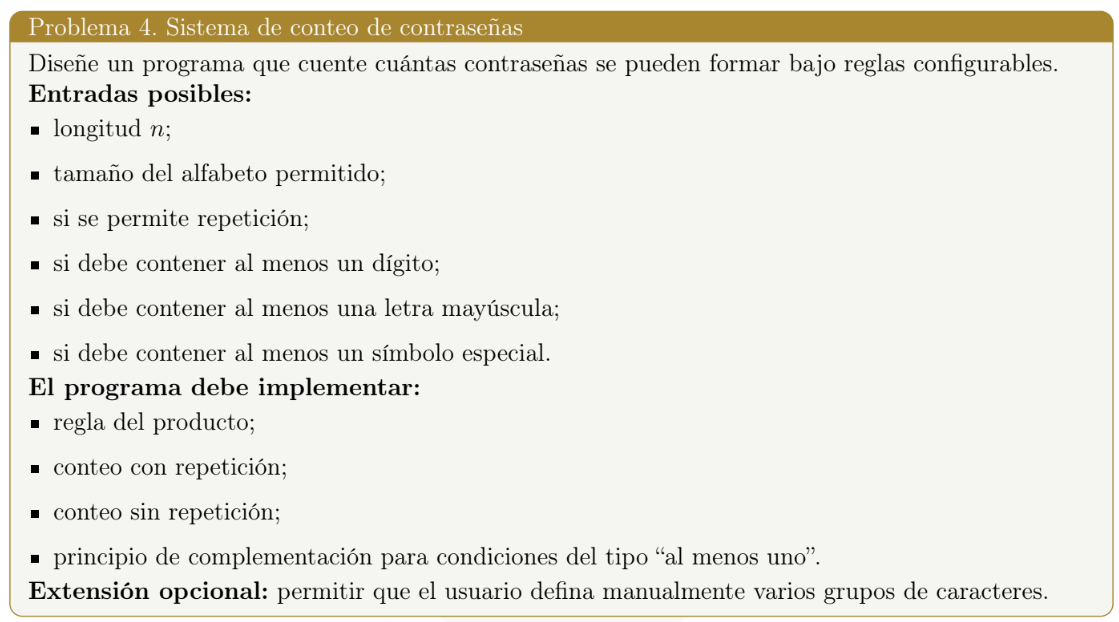

#1. Explicación del problema


---



El objetivo principal es calcular de manera exacta cuántas contraseñas distintas se pueden generar bajo un conjunto de reglas altamente configurables. El sistema no genera las contraseñas una por una, sino que calcula el total aplicando principios de análisis combinatorio.

El problema radica en que el usuario puede activar restricciones del tipo "al menos un carácter de este grupo" (mayúsculas, dígitos o símbolos). Esto transforma un conteo simple en un problema donde los conjuntos se intersectan, obligando a filtrar de forma precisa las combinaciones válidas de las inválidas según los tamaños de abecedario definidos.

#2. Formula o principio combinatorio usado


---





El programa calcula el total de contraseñas válidas utilizando tres herramientas de la matemática discretas:

### A. Conteo con repetición (Regla del producto)
Cuando el usuario permite repetir caracteres, cada espacio de la contraseña tiene siempre el mismo número de opciones disponibles ($U$). El programa realiza este cálculo en la función `calcular_arreglos_posibles` usando una potencia:
* **Fórmula:** $\text{Resultado} = U^{\text{longitud}}$
* **En el código:** Se ejecuta como `total_caracteres ** longitud`.

### B. Conteo sin repetición (Permutaciones)
Cuando el usuario no permite repetir caracteres, las opciones disponibles se van "gastando" en cada espacio de la contraseña. El programa implementa dos funciones propias para resolver esto:
1. `factorialnumero(n)`: Realiza la multiplicación descendente consecutiva ($n!$).
2. `permutacionNumero(n, r)`: Aplica la fórmula de permutaciones: $P(n, r) = \frac{n!}{(n-r)!}$.

### C. Principio del Complemento
Intentar contar directamente las contraseñas que tienen "al menos un" carácter obligatorio es un proceso complejo. La función `calcular_conteo` simplifica el problema restando los casos inválidos del total:
* **Lógica:** $\text{Contraseñas Válidas} = \text{Total Universo} - \text{Casos Prohibidos}$.
* **Proceso:** La función `calcular_casos_prohibidos` detecta las combinaciones que olvidaron incluir los grupos obligatorios.

#### Inclusión-Exclusión
Si el usuario activa varias reglas obligatorias (ejemplo: Mayúsculas y Dígitos), el programa resta las contraseñas sin mayúsculas y las que no tienen dígitos.
* **El ajuste:** Como algunas contraseñas (las que no tienen ni mayúsculas ni dígitos) se restaron dos veces por error, el programa aplica el **Principio de Inclusión-Exclusión** en las **Fases B y C**. Esto consiste en sumar de vuelta las intersecciones para equilibrar la balanza y obtener un resultado exacto.

#3. Algoritmo implementado


---





El programa se organiza en cuatro etapas para transformar los requisitos del sistema en un cálculo matemático preciso:

1. **Captura y configuración:** El programa solicita al usuario la longitud ($n$) y los tamaños de los grupos de caracteres. Si se elige la "Caracteres Personalizados", permite definir manualmente el tamaño de mayúsculas, dígitos y símbolos. Se incluyen validaciones para impedir errores de lógica, como solicitar una contraseña sin repetición más larga que el total de caracteres disponibles.

2. **Cálculo del Universo Bruto:** El sistema suma todos los tamaños de los grupos activos para obtener el total de opciones ($U$). Dependiendo de si se permite la repetición, utiliza una potencia ($U^n$) o la función `permutacionNumero` para calcular el total de combinaciones posibles sin aplicar restricciones.

3. **Análisis de restricciones (Inclusión-Exclusión):** Esta es la parte central del algoritmo. La función `calcular_casos_prohibidos` sigue estos pasos:
    * **Fase A:** Calcula cuántas contraseñas se formaron incorrectamente al olvidar cada grupo obligatorio individualmente.
    * **Fase B:** Corrige el error de "doble resta" detectando las combinaciones que fueron descontadas dos veces al faltar dos grupos simultáneamente.
    * **Fase C:** Realiza el ajuste final de la intersección triple si el usuario requiere los tres grupos, asegurando que las contraseñas sin nada (solo alfabeto base) se procesen correctamente.

4. **Resultado :** Finalmente, el programa realiza la sustracción: $\text{Total} - \text{Inválidas}$. .

#4. Codigo Funcional

Funciones




In [ ]:
def bienvenida():
    """
    Imprime en la terminal el encabezado estético y la presentación inicial del programa.
    """
    texto = """
-----------------------------------------------------------------------------------------------------------------
                                     SISTEMA DE CONTEO DE CONTRASEÑAS
-----------------------------------------------------------------------------------------------------------------

Este programa nos permite calcular cuántas contraseñas se pueden formar bajo reglas configurables.

"""
    print(texto)

def menu():
    """
    Despliega el menú principal y solicita al usuario una opción válida (0, 1 o 2).
    """
    print("..................................................")
    print("                     MENÚ")
    print("..................................................\n")

    print("0. Salir del programa")
    print("1. Caracteres predeterminados")
    print("2. Caracteres personalizados (Extensión)")

    while True:
        try:
            x = int(input("\nEscriba la opción que desea realizar: "))
            if x in [0, 1, 2]:
                break
            else:
                print("Opción inválida. Por favor, elige 0, 1, o 2.\n")
        except ValueError:
            print("Por favor, ingresa solo números enteros.\n")

    if x == 0:
        print("\n-----------------------------------------------------------------------------------------------------------------")
        print("                                                    FIN PROGRAMA")
        print("-----------------------------------------------------------------------------------------------------------------")
    elif x == 1:
        print("\n-----------------------------------------------------------------------------------------------------------------")
        print("                                Opcion 1. Caracteres predeterminados")
        print("-----------------------------------------------------------------------------------------------------------------")
    elif x == 2:
        print("\n-----------------------------------------------------------------------------------------------------------------")
        print("                                Opcion 2. Caracteres personalizados")
        print("-----------------------------------------------------------------------------------------------------------------")

    return x

def verificarnum(mensaje):
    """
    Valida de forma robusta que el usuario ingrese un número entero mayor a cero.
    """
    while True:
        try:
            x = int(input(mensaje))
            if x > 0:
                break
            print("Valor ingresado inválido. Recuerde que el número debe ser mayor que cero.\n")
        except ValueError:
            print("Por favor, ingresa solo números enteros positivos.\n")
    return x

def verificar_limite_digitos(mensaje):
    """
    Valida que la cantidad de dígitos personalizados esté en el rango (1 a 10).
    """
    while True:
        try:
            x = int(input(mensaje))
            if x > 0 and x <= 10:
                break
            print("Valor ingresado inválido. Recuerde que el número debe ser un entero positivo entre 1 y 10.\n")
        except ValueError:
            print("Por favor, ingresa solo números enteros.\n")
    return x

def verificarSiNo(mensaje):
    """
    Valida de forma estricta que el usuario responda únicamente 'si' o 'no'.
    """
    while True:
        x = input(mensaje).lower().strip()
        if x == "si":
            return True
        if x == "no":
            return False
        print("Respuesta inválida. Por favor, responda con 'si' o 'no'.\n")

def recopilar_configuracion(opcion):
    """
    Solicita y valida todas las reglas. Calcula dinámicamente el total de opciones de caracteres
    para garantizar que la longitud no rompa el programa si no hay repetición.
    """
    if opcion == 1:
        prede = """
[Info] Modo Predeterminado Activo:
- Alfabeto base (ej. minúsculas): Definido por el usuario
- Mayúsculas: 26 letras fijas
- Dígitos: 10 fijos (del 0 al 9)
- Símbolos especiales: 10 fijos (*, =, /, !, #, %, &, +, @, ?)
"""
        print(prede)

    while True:
        longitud = verificarnum("Ingrese la longitud deseada de la contraseña (n): ")
        alfabeto_base = verificarnum("Ingrese el tamaño del alfabeto base (ej. 26 para letras minúsculas): ")
        repeticion = verificarSiNo("¿Desea que se permita repetición de caracteres? ('Si' o 'No'): ")

        mayuscula = verificarSiNo("¿Debe contener al menos una letra mayúscula? ('Si' o 'No'): ")
        digito = verificarSiNo("¿Debe contener al menos un dígito? ('Si' o 'No'): ")
        simbolo = verificarSiNo("¿Debe contener al menos un símbolo especial? ('Si' o 'No'): ")

        # Valores por defecto para el Modo Predeterminado (Opción 1)
        cant_mayusculas = 26
        cant_digitos = 10
        cant_simbolos = 10

        # Si es la Opción 2 (Extensión), el usuario define los tamaños manualmente
        if opcion == 2:
            print("\n--- Configuración de Extensión ---")
            if mayuscula:
                cant_mayusculas = verificarnum("Ingrese cuántas letras MAYÚSCULAS distintas permite usar: ")
            if digito:
                cant_digitos = verificar_limite_digitos("Ingrese cuántos DÍGITOS distintos permite usar (1 al 10): ")
            if simbolo:
                cant_simbolos = verificarnum("Ingrese cuántos SÍMBOLOS especiales distintos permite usar: ")
            print("----------------------------------\n")

        # Calculamos el total de opciones
        universo_temporal = alfabeto_base
        if mayuscula: universo_temporal += cant_mayusculas
        if digito:    universo_temporal += cant_digitos
        if simbolo:   universo_temporal += cant_simbolos

        # Validación
        if not repeticion and longitud > universo_temporal:
            print(f"\n ERROR DE LÓGICA:")
            print(f"Elegiste 'Sin Repetición' para una contraseña de {longitud} caracteres, ")
            print(f"pero tu configuración solo te da {universo_temporal} caracteres disponibles en total.")
            print("Es matemáticamente imposible crear una contraseña tan larga sin repetir caracteres. Reconfigura las reglas.\n")
            print("..................................................\n")
        else:
            break

    return longitud, alfabeto_base, repeticion, digito, mayuscula, simbolo, cant_mayusculas, cant_digitos, cant_simbolos


def factorialnumero(n):
    """Calcula el factorial de forma iterativa."""
    if n == 0:
        return 1
    x = 1
    for i in range(1, n + 1):
        x = x * i
    return x

def permutacionNumero(n, r):
    """Cálculo de permutación sin repetición P(n,r)."""
    if n < r:
        return 0
    return factorialnumero(n) // factorialnumero(n - r)

def calcular_arreglos_posibles(total_caracteres, longitud, repeticion):
    """Calcula el total de arreglos aplicando la Regla del Producto o Permutación."""
    if repeticion:
        return total_caracteres ** longitud
    else:
        return permutacionNumero(total_caracteres, longitud)

def format_operacion(total_caracteres, longitud, repeticion):
    """Genera una explicación en texto simple de lo que hace la matemática."""
    if repeticion:
        return f"{total_caracteres} elevado a la {longitud}"
    else:
        return f"Permutación de {total_caracteres} caracteres en {longitud} espacios (sin repetir)"


def calcular_casos_prohibidos(longitud, U, repeticion, mayuscula, digito, simbolo, cant_mayusculas, cant_digitos, cant_simbolos):
    """
    Calcula cuántas contraseñas se armaron mal (rompiendo las condiciones de 'al menos uno')
    """
    invalidas = 0

    print(" [2] BUSCANDO CONTRASEÑAS INCORRECTAS (Las que rompen las reglas):")
    print("     Vamos a descubrir cuántas combinaciones se crearon olvidando los grupos obligatorios.\n")

    multiples_reglas = (int(mayuscula) + int(digito) + int(simbolo)) > 1

    if multiples_reglas:
        print("     Fase A: Contando contraseñas a las que les falta un grupo obligatorio:")

    # 1. Falta un grupo obligatorio
    if mayuscula:
        p = U - cant_mayusculas
        op = format_operacion(p, longitud, repeticion)
        res = calcular_arreglos_posibles(p, longitud, repeticion)
        invalidas += res
        print(f"        [-] Contraseñas creadas SIN MAYÚSCULAS:")
        print(f"            Se armaron usando solo {p} caracteres disponibles. Cálculo: {op} = {res:,} incorrectas.")
    if digito:
        p = U - cant_digitos
        op = format_operacion(p, longitud, repeticion)
        res = calcular_arreglos_posibles(p, longitud, repeticion)
        invalidas += res
        print(f"        [-] Contraseñas creadas SIN DÍGITOS:")
        print(f"            Se armaron usando solo {p} caracteres disponibles. Cálculo: {op} = {res:,} incorrectas.")
    if simbolo:
        p = U - cant_simbolos
        op = format_operacion(p, longitud, repeticion)
        res = calcular_arreglos_posibles(p, longitud, repeticion)
        invalidas += res
        print(f"        [-] Contraseñas creadas SIN SÍMBOLOS:")
        print(f"            Se armaron usando solo {p} caracteres disponibles. Cálculo: {op} = {res:,} incorrectas.")

    # 2. Faltan dos grupos a la vez (Intersecciones dobles)
    tiene_interseccion_doble = (mayuscula and digito) or (mayuscula and simbolo) or (digito and simbolo)
    if tiene_interseccion_doble:
        print("\n     Fase B: Corrigiendo contraseñas que se contaron dos veces repetidas:")
        print("             (Al restar los grupos anteriores, algunas contraseñas vacías se descontaron doble, así que las devolvemos)")

        if mayuscula and digito:
            p = U - cant_mayusculas - cant_digitos
            op = format_operacion(p, longitud, repeticion)
            res = calcular_arreglos_posibles(p, longitud, repeticion)
            invalidas -= res
            print(f"        [+] Sin Mayúsculas ni Dígitos a la vez: Usan {p} caracteres ({op}) = +{res:,} devueltas.")
        if mayuscula and simbolo:
            p = U - cant_mayusculas - cant_simbolos
            op = format_operacion(p, longitud, repeticion)
            res = calcular_arreglos_posibles(p, longitud, repeticion)
            invalidas -= res
            print(f"        [+] Sin Mayúsculas ni Símbolos a la vez: Usan {p} caracteres ({op}) = +{res:,} devueltas.")
        if digito and simbolo:
            p = U - cant_digitos - cant_simbolos
            op = format_operacion(p, longitud, repeticion)
            res = calcular_arreglos_posibles(p, longitud, repeticion)
            invalidas -= res
            print(f"        [+] Sin Dígitos ni Símbolos a la vez: Usan {p} caracteres ({op}) = +{res:,} devueltas.")

    # 3. Faltan los tres grupos (Intersección triple)
    if mayuscula and digito and simbolo:
        print("\n     Fase C: Ajuste final del centro matemático:")
        print("             (Contraseñas que no tienen ni mayúsculas, ni dígitos, ni símbolos. Solo tienen letras del alfabeto base)")
        p = U - cant_mayusculas - cant_digitos - cant_simbolos
        op = format_operacion(p, longitud, repeticion)
        res = calcular_arreglos_posibles(p, longitud, repeticion)
        invalidas += res
        print(f"        [-] Sin ninguno de los tres grupos: Usan sólo {p} caracteres ({op}) = -{res:,} eliminadas de nuevo.")

    print(f"\n     => Total de combinaciones incorrectas que debemos eliminar: {invalidas:,}")
    return invalidas

def calcular_conteo(longitud, alfabeto_base, repeticion, digito, mayuscula, simbolo, cant_mayusculas, cant_digitos, cant_simbolos):
    """Coordina el cálculo final e imprime el desglose didáctico completo."""

    # Calcular el total de opciones de caracteres sumando los grupos activos
    U = alfabeto_base
    texto_caracteres = f"{alfabeto_base} del alfabeto base"
    if mayuscula:
        U += cant_mayusculas
        texto_caracteres += f" + {cant_mayusculas} mayúsculas"
    if digito:
        U += cant_digitos
        texto_caracteres += f" + {cant_digitos} dígitos"
    if simbolo:
        U += cant_simbolos
        texto_caracteres += f" + {cant_simbolos} símbolos especiales"

    print("\n" + "="*85)
    print(f"{'DESGLOSE PASO A PASO':^85}")
    print("="*85)

    # 1. Arreglos Totales en bruto
    total_universo = calcular_arreglos_posibles(U, longitud, repeticion)
    op_u = format_operacion(U, longitud, repeticion)

    print(f" [1] TOTAL DE COMBINACIONES POSIBLES (Sin importar las reglas):")
    print(f"     Tenemos un total de {U} caracteres disponibles para elegir ({texto_caracteres}).")
    if repeticion:
        print(f"     Como se permite repetir caracteres en una contraseña de {longitud} espacios:")
        print(f"     Multiplicamos {U} opciones para cada espacio ({op_u}).")
    else:
        print(f"     Como NO se permite repetir caracteres en una contraseña de {longitud} espacios:")
        print(f"     Calculamos las posiciones disponibles: {op_u}.")
    print(f"     => Resultado: {total_universo:,} combinaciones totales en bruto.\n")
    print(" " + "-"*81)

    # 2. Restar Complementos Prohibidos
    total_prohibidas = calcular_casos_prohibidos(longitud, U, repeticion, mayuscula, digito, simbolo, cant_mayusculas, cant_digitos, cant_simbolos)
    total_validas = total_universo - total_prohibidas

    # 3. Cierre
    print(" " + "-"*81)
    print(f" [3] CÁLCULO FINAL (El descarte):")
    print(f"     Para saber cuántas cumplen las reglas, al total bruto le quitamos las incorrectas:")
    print(f"     {total_universo:,} (Totales) - {total_prohibidas:,} (Incorrectas) = {total_validas:,} válidas.")
    print("="*85 + "\n")

    return total_validas



#4. Codigo Funcional

Programa principal


In [ ]:
def main():
    bienvenida()

    while True:
        opcion = menu()

        if opcion == 0:
            break

        elif opcion in [1, 2]:
            (longitud, alfabeto_base, repeticion,
             digito, mayuscula, simbolo,
             cant_mayusculas, cant_digitos, cant_simbolos) = recopilar_configuracion(opcion)

            resultado = calcular_conteo(longitud, alfabeto_base, repeticion, digito, mayuscula, simbolo, cant_mayusculas, cant_digitos, cant_simbolos)

            print("=================================================================================================================")
            print(f" RESULTADO FINAL: Se pueden formar {resultado:,} contraseñas válidas y seguras.")
            print("=================================================================================================================\n")

        continuar = verificarSiNo("¿Desea realizar otro cálculo? (si/no): ")
        if not continuar:
            print("\n-----------------------------------------------------------------------------------------------------------------")
            print("                                                    FIN PROGRAMA")
            print("-----------------------------------------------------------------------------------------------------------------")
            break

main()

#5. Pruebas


Para demostrar la estabilidad del programa, se ejecutó una prueba real por cada una de las opciones disponibles en el menú interactivo, organizadas secuencialmente:



### Prueba 1: Caso de Control (Configuración Base con Repetición)
* **Opción seleccionada en el menú:** Opción 1 (Caracteres predeterminados)
* **Datos ingresados:** Longitud ($n$) = 4 | Alfabeto base = 6 | Permitir repetición = Si | ¿Al menos Mayúscula? = No | ¿Al menos Dígito? = Si | ¿Al menos Símbolo? = No
* **Procedimiento en pantalla:** El programa calcula el abanico total de caracteres sumando el alfabeto base y los 10 dígitos predeterminados ($6 + 10 = 16$). Evalúa el Universo total ($16^4$) y le resta las combinaciones incorrectas que no llevan dígitos ($6^4$).
* **Resultado obtenido:** `64,240`




### Prueba 2: Caso de Alta Complejidad (Principio de Inclusión-Exclusión)
* **Opción seleccionada en el menú:** Opción 1 (Caracteres predeterminados)
* **Datos ingresados:** Longitud ($n$) = 3 | Alfabeto base = 10 | Permitir repetición = Si | ¿Al menos Mayúscula? = Si | ¿Al menos Dígito? = Si | ¿Al menos Símbolo? = No
* **Procedimiento en pantalla:** El programa detecta múltiples condiciones obligatorias. Calcula el Universo ($10 + 26 + 10 = 46$) elevado a la 3, resta los casos individuales sin mayúsculas y sin dígitos (Fase A) y restituye la intersección de las contraseñas que carecían de ambos grupos a la vez (Fase B).
* **Resultado obtenido:** `43,680`




### Prueba 3: Caso Sencillo Sin Repetición (Permutaciones)
* **Opción seleccionada en el menú:** Opción 1 (Caracteres predeterminados)
* **Datos ingresados:** Longitud ($n$) = 3 | Alfabeto base = 5 | Permitir repetición = No | ¿Al menos Mayúscula? = Si | ¿Al menos Dígito? = No | ¿Al menos Símbolo? = No
* **Procedimiento en pantalla:** El algoritmo detecta que no se permite repetir y cambia su nomenclatura a permutaciones. Suma los caracteres disponibles ($5 + 26 = 31$). Calcula el Universo bruto como $P(31, 3)$ y le resta las combinaciones prohibidas sin mayúsculas calculadas como $P(5, 3)$.
* **Resultado obtenido:** `26,910`




### Prueba 4: Caso con Triple Restricción Simultánea
* **Opción seleccionada en el menú:** Opción 1 (Caracteres predeterminados)
* **Datos ingresados:** Longitud ($n$) = 3 | Alfabeto base = 2 | Permitir repetición = Si | ¿Al menos Mayúscula? = Si | ¿Al menos Dígito? = Si | ¿Al menos Símbolo? = Si
* **Procedimiento en pantalla:** Activa el cálculo completo del Principio de Inclusión-Exclusión. Pasa secuencialmente por la Fase A (restar ausencias individuales), Fase B (sumar intersecciones dobles) y Fase C (restar la intersección triple de contraseñas vacías formadas solo por el alfabeto base).
* **Resultado obtenido:** `31,200`




### Prueba 5: Caso de Extensión (Configuración de Tamaños Personalizados)
* **Opción seleccionada en el menú:** Opción 2 (Caracteres personalizados)
* **Datos ingresados:** Longitud ($n$) = 4 | Alfabeto base = 10 | Permitir repetición = Si | ¿Al menos Mayúscula? = No | ¿Al menos Dígito? = Si (Tamaño: 5) | ¿Al menos Símbolo? = Si (Tamaño: 2)
* **Procedimiento en pantalla:** Habilita el módulo de extensión. El sistema solicita manualmente los límites de los grupos obligatorios en lugar de usar los valores fijos. Consolida el total de opciones en 17 ($10 + 5 + 2$) y ejecuta el descarte con base en las dimensiones ingresadas por el usuario.
* **Resultado obtenido:** `50,040`


#6. Validación casos especiales



El algoritmo verifica los datos ingresados mediante:

* **Gestión de incompatibilidad lógica:** Si el usuario elige "Sin repetición" pero solicita una contraseña más larga que el total de caracteres disponibles, el programa `recopilar_configuracion` detecta la contradicción de inmediato. En lugar de procesar un error, el sistema detiene la ejecución y solicita una reconfiguración, ya que es imposible construir una cadena única sin repetir elementos cuando la longitud supera al abanico de opciones.

* **Protección ante datos inválidos:** Mediante las funciones `verificarnum` y `verificar_limite_digitos`, el programa utiliza bloques de control *try-except*. Si se introducen letras o símbolos donde se requieren números, el sistema no se interrumpe; simplemente descarta la entrada incorrecta y solicita el valor nuevamente, manteniendo la integridad del flujo de trabajo.

* **Control de rangos en configuraciones personalizadas:** Para la extensión opcional, la función `verificar_limite_digitos` limita el valor de los grupos a un rango de 1 a 10. Esto asegura que la configuración se mantenga dentro de los límites reales del sistema decimal.

* **Filtrado estricto de respuestas binarias:** El sistema emplea la función `verificarSiNo` para normalizar las respuestas del usuario. Cualquier entrada que no sea estrictamente "si" o "no" es rechazada por el programa y pide ingresar nuevamente los datos.

#7. Eficiencia del algoritmo



El programa está diseñado para trabajar con rapidez y precisión, sin importar qué tan grande sea el resultado. Su eficiencia se basa en tres puntos clave:

* **Rapidez instantánea:** El programa listar cada contraseña una por una. En su lugar, utiliza fórmulas matemáticas directas que obtienen el resultado en microsegundos, sin importar si la contraseña es corta o extremadamente larga.

* **Bajo consumo de memoria:** Al realizar cálculos matemáticos como potencias o factoriales, el sistema no necesita guardar grandes cantidades de datos. Solo maneja unas pocas variables numéricas, lo que permite que el programa funcione perfectamente .
